In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
station_day_data = '/content/drive/My Drive/impact_metrics/station_day_imp.csv'
station_metadata = '/content/drive/My Drive/impact_metrics/stations.csv'

In [4]:
df = pd.read_csv(station_day_data)
df_meta = pd.read_csv(station_metadata)

In [5]:
cols = ['PM2.5', 'PM10', 'NO',	'NO2',	'NOx',	'NH3',	'CO',	'SO2',	'O3',	'Benzene',	'Toluene',	'Xylene']

In [6]:
station_avgs = df.groupby('StationId')[cols].mean()
station_avgs.columns = [f'{col}_avg' for col in cols]

In [7]:
station_avgs

,PM2.5_avg,PM10_avg,NO_avg,NO2_avg,NOx_avg,NH3_avg,CO_avg,SO2_avg,O3_avg,Benzene_avg,Toluene_avg,Xylene_avg
StationId,,,,,,,,,,,,
AP001,36.416698,74.005594,5.038370,21.782376,15.261209,12.419369,0.609248,14.350042,37.409790,0.644968,1.990131,1.891572
AP005,44.674555,102.852233,12.262432,35.770657,25.372185,10.761289,0.738912,12.416587,35.334111,3.906252,8.381477,2.813382
BR005,32.536111,94.155397,72.281587,26.925238,26.818968,17.929881,0.536190,5.390397,43.763175,2.932540,4.066111,0.522698
BR006,42.957107,147.695537,4.886033,8.733140,9.563306,11.257397,0.626198,7.484793,7.044380,2.621901,0.379587,2.718430
BR007,110.913685,108.015410,24.713746,38.136233,41.168949,17.442457,1.478974,20.465837,36.585260,1.248906,8.404391,3.932349
...,...,...,...,...,...,...,...,...,...,...,...,...
WB009,53.873593,99.536457,23.493442,33.800905,54.900603,15.384045,0.619070,6.399146,30.085879,10.008166,18.449849,2.906005
WB010,40.597165,80.530911,29.139772,23.724532,52.102152,17.939772,0.730937,5.898582,20.488051,59.074367,59.164620,3.383430
WB011,86.583336,167.817657,23.838204,46.958038,68.215778,24.318377,0.501159,13.277856,35.770050,6.963394,13.146126,2.272666


In [8]:
station_avgs.to_csv('avgs.csv')

In [9]:
print('Top 5 Polluted Stations by Pollutant (over 5 years)')
hotspots_by_pollutant = {}
for col in cols:
  avg_col = f'{col}_avg'
  top_stations = station_avgs.sort_values(by=avg_col, ascending = False).head(5)
  station_city_map = df[['StationId', 'City', 'StationName', 'State']].drop_duplicates().set_index('StationId')
  top_stations = top_stations.merge(station_city_map, left_index=True, right_index=True, how='left')
  hotspots_by_pollutant[col] = top_stations[['City', avg_col]].reset_index()
  print(f"\nTop 5 Hotspots for {col}")
  print(top_stations[['StationName', 'City', 'State', avg_col]])

Top 5 Polluted Stations by Pollutant (over 5 years)

Top 5 Hotspots for PM2.5
                          StationName   City  State   PM2.5_avg
StationId                                                      
DL002       Anand Vihar, Delhi - DPCC  Delhi  Delhi  143.004486
DL015      Jahangirpuri, Delhi - DPCC  Delhi  Delhi  128.074263
DL038          Wazirpur, Delhi - DPCC  Delhi  Delhi  127.298719
DL032            Rohini, Delhi - DPCC  Delhi  Delhi  122.253639
DL020            Mundka, Delhi - DPCC  Delhi  Delhi  122.246863

Top 5 Hotspots for PM10
                             StationName   City  State    PM10_avg
StationId                                                         
DL002          Anand Vihar, Delhi - DPCC  Delhi  Delhi  342.644872
DL010      Dwarka-Sector 8, Delhi - DPCC  Delhi  Delhi  276.756224
DL038             Wazirpur, Delhi - DPCC  Delhi  Delhi  275.853798
DL020               Mundka, Delhi - DPCC  Delhi  Delhi  269.154616
DL015         Jahangirpuri, Delhi - DPCC  Delhi

In [10]:
avg_aqi_ranking = df.groupby('StationId')['AQI'].mean().sort_values(ascending=False)
top_aqi_df = avg_aqi_ranking.head(5).reset_index()
station_city_map = df[['StationId', 'City']].drop_duplicates().set_index('StationId')
top_aqi_df = top_aqi_df.merge(station_city_map.reset_index(), on='StationId', how='left')

print("Top Stations by Average AQI(Overall Severity)")
print(top_aqi_df[['StationId', 'City', 'AQI']].rename(columns={'AQI': 'Average_AQI'}))

Top Stations by Average AQI(Overall Severity)
  StationId     City  Average_AQI
0     DL005    Delhi   310.903206
1     DL002    Delhi   285.554600
2     WB010  Kolkata   279.783629
3     DL038    Delhi   262.537676
4     DL020    Delhi   254.129082


In [11]:
top_aqi_df.to_csv('aqi.csv')

In [12]:
bad_air_categories = ['Poor', 'Very Poor', 'Severe']

total_days_counts = df.groupby('StationId').size().rename('total_days_counts')

df_bad_days = df[df['AQI_Bucket'].isin(bad_air_categories)]
bad_day_counts = df_bad_days.groupby('StationId').size().rename('bad_day_counts')

aqi_hotspot_ranking = pd.merge(total_days_counts, bad_day_counts, left_index=True, right_index=True, how='left')

aqi_hotspot_ranking['percent_bad_air'] = (aqi_hotspot_ranking['bad_day_counts'] / aqi_hotspot_ranking['total_days_counts']) * 100

top_frequency_df = aqi_hotspot_ranking.sort_values(by='percent_bad_air', ascending=False).head(5).reset_index()

top_frequency_df = top_frequency_df.merge(station_city_map.reset_index(), on='StationId', how='left')

print("Top Stations by Percentage of Bad Air Days")
print(top_frequency_df[['StationId', 'City', 'percent_bad_air']])

Top Stations by Percentage of Bad Air Days
  StationId     City  percent_bad_air
0     DL005    Delhi        89.437586
1     DL002    Delhi        69.415449
2     WB010  Kolkata        68.354430
3     DL021    Delhi        66.002987
4     DL038    Delhi        64.625850


In [13]:
top_frequency_df[['StationId', 'City', 'percent_bad_air']].to_csv('bad_air_days.csv')

# City

In [14]:
df_city = pd.read_csv('/content/drive/My Drive/impact_metrics/city_day_imp.csv')

In [15]:
city_avgs = df_city.groupby('City')[cols].mean()
city_avgs.columns = [f'{col}_avg' for col in cols]

In [16]:
city_avgs.to_csv('city_avgs.csv')

In [17]:
print('Top 5 Polluted Cities by Pollutant (over 5 years)')
hotspots_by_pollutant = {}
for col in cols:
  avg_col = f'{col}_avg'
  top_cities = city_avgs.sort_values(by=avg_col, ascending = False).head(5)
  hotspots_by_pollutant[col] = top_cities[[avg_col]].reset_index()
  print(f"\nTop 5 Hotspots for {col}")
  print(top_cities[[avg_col]])

Top 5 Polluted Cities by Pollutant (over 5 years)

Top 5 Hotspots for PM2.5
            PM2.5_avg
City                 
Gurugram   120.467147
Delhi      117.101215
Patna      113.452196
Lucknow    112.098036
Ahmedabad   68.179990

Top 5 Hotspots for PM10
                PM10_avg
City                    
Delhi         231.171429
Gurugram      192.807129
Talcher       164.245492
Jorapokhar    148.415304
Brajrajnagar  129.208518

Top 5 Hotspots for NO
            NO_avg
City              
Kochi    70.900247
Delhi    38.971533
Talcher  32.974649
Mumbai   32.898333
Patna    30.185775

Top 5 Hotspots for NO2
                 NO2_avg
City                    
Ahmedabad      53.971685
Delhi          50.769856
Kolkata        39.879509
Patna          36.274532
Visakhapatnam  35.803119

Top 5 Hotspots for NOx
           NOx_avg
City              
Kochi    68.412901
Kolkata  63.343489
Delhi    58.567023
Mumbai   54.867354
Patna    44.969085

Top 5 Hotspots for NH3
                NH3_avg
City      

In [18]:
avg_aqi_ranking = df_city.groupby('City')['AQI'].mean().sort_values(ascending=False)
top_aqi_df_city = avg_aqi_ranking.head(5).reset_index()

print("Top Cities by Average AQI(Overall Severity)")
print(top_aqi_df_city[['City','AQI']].rename(columns={'AQI': 'Average_AQI'}))

Top Cities by Average AQI(Overall Severity)
        City  Average_AQI
0  Ahmedabad   273.212282
1      Delhi   234.397065
2   Gurugram   229.592300
3    Lucknow   218.160884
4      Patna   206.589383


In [19]:
bad_air_categories = ['Poor', 'Very Poor', 'Severe']

total_days_counts = df_city.groupby('City').size().rename('total_days_counts')

df_city_bad_days = df_city[df_city['AQI_Bucket'].isin(bad_air_categories)]
bad_day_counts = df_city_bad_days.groupby('City').size().rename('bad_day_counts')

aqi_hotspot_ranking = pd.merge(total_days_counts, bad_day_counts, left_index=True, right_index=True, how='left')

aqi_hotspot_ranking['percent_bad_air'] = (aqi_hotspot_ranking['bad_day_counts'] / aqi_hotspot_ranking['total_days_counts']) * 100

top_frequency_df_city = aqi_hotspot_ranking.sort_values(by='percent_bad_air', ascending=False).head(5).reset_index()

print("Top Cities by Percentage of Bad Air Days")
print(top_frequency_df_city[['City', 'percent_bad_air']])

Top Cities by Percentage of Bad Air Days
        City  percent_bad_air
0  Ahmedabad        77.401692
1      Delhi        54.703833
2    Lucknow        51.816824
3   Gurugram        50.863609
4      Patna        44.940797


# unexpected pattern
plausibly attributed to CO value(Ahmedabad avg is significantly higher than others; also it has values like 132 which seem not too practical)<br>
hence repeating the AQI calcs for cities excluding CO

In [20]:
#CO is in mg/m3; all others are in ug/m3.
AQI_BREAKPOINTS = {
    (0, 50): [  # Good
        (0, 30.0, 'PM2.5'), (0, 50.0, 'PM10'), (0, 40.0, 'NO2'), (0, 60.0, 'O3'),
        (0, 40.0, 'SO2'), (0, 200.0, 'NH3'), (0, 5.0, 'Benzene'),
        (0, 14.0, 'Toluene'), (0, 17.0, 'Xylene')
    ],
    (51, 100): [ # Satisfactory
        (31.0, 60.0, 'PM2.5'), (51.0, 100.0, 'PM10'), (41.0, 80.0, 'NO2'), (61.0, 100.0, 'O3'),
        (41.0, 80.0, 'SO2'), (201.0, 400.0, 'NH3'), (5.1, 10.0, 'Benzene'),
        (14.1, 40.0, 'Toluene'), (17.1, 40.0, 'Xylene')
    ],
    (101, 200): [ # Moderate
        (61.0, 90.0, 'PM2.5'), (101.0, 250.0, 'PM10'), (81.0, 180.0, 'NO2'), (101.0, 168.0, 'O3'),
        (2.1, 10.0, 'CO'), (81.0, 380.0, 'SO2'), (401.0, 800.0, 'NH3'), (10.1, 17.0, 'Benzene'),
        (40.1, 80.0, 'Toluene'), (40.1, 80.0, 'Xylene')
    ],
    (201, 300): [ # Poor
        (91.0, 120.0, 'PM2.5'), (251.0, 350.0, 'PM10'), (181.0, 280.0, 'NO2'), (169.0, 208.0, 'O3'),
        (381.0, 800.0, 'SO2'), (801.0, 1200.0, 'NH3'), (17.1, 34.0, 'Benzene'),
        (80.1, 120.0, 'Toluene'), (80.1, 120.0, 'Xylene')
    ],
    (301, 400): [ # Very Poor
        (121.0, 250.0, 'PM2.5'), (351.0, 430.0, 'PM10'), (281.0, 400.0, 'NO2'), (209.0, 748.0, 'O3'),
        (801.0, 1600.0, 'SO2'), (1201.0, 1800.0, 'NH3'), (34.1, 50.0, 'Benzene'),
        (120.1, 240.0, 'Toluene'), (120.1, 240.0, 'Xylene')
    ],
    (401, 500): [ # Severe
        (251.0, 9999.0, 'PM2.5'), (431.0, 9999.0, 'PM10'), (401.0, 9999.0, 'NO2'), (749.0, 9999.0, 'O3'),
        (1601.0, 9999.0, 'SO2'), (1801.0, 9999.0, 'NH3'), (50.1, 9999.0, 'Benzene'),
        (240.1, 9999.0, 'Toluene'), (240.1, 9999.0, 'Xylene')
    ]
}


def get_pollutant_index(pollutant_name):
    pollutant_order = ['PM2.5', 'PM10',	'NO2',	'NH3',	'SO2',	'O3',	'Benzene',	'Toluene',	'Xylene']
    try:
        return pollutant_order.index(pollutant_name)
    except ValueError:
        return -1

def calculate_sub_index(pollutant_conc, pollutant_name, breakpoints):
    if pd.isna(pollutant_conc) or pollutant_conc < 0:
        return np.nan

    map_index = get_pollutant_index(pollutant_name)
    if map_index == -1:
        return np.nan

    for (I_L, I_H), pollutant_ranges in breakpoints.items():
        try:
            B_L, B_H, _ = pollutant_ranges[map_index]
        except IndexError:
            continue

        if pollutant_conc >= B_L and pollutant_conc <= B_H:
            # Ip = [(I_H - I_L) / (B_H - B_L)] * (C_p - B_L) + I_L
            if B_H == B_L:
                 return I_H

            Ip = ((I_H - I_L) / (B_H - B_L)) * (pollutant_conc - B_L) + I_L
            return Ip

        if I_H == 500 and pollutant_conc > B_H:
            return 500.0

    return np.nan

def determine_aqi_bucket(aqi_value):
    if pd.isna(aqi_value):
        return np.nan
    elif aqi_value <= 50:
        return 'Good'
    elif aqi_value <= 100:
        return 'Satisfactory'
    elif aqi_value <= 200:
        return 'Moderate'
    elif aqi_value <= 300:
        return 'Poor'
    elif aqi_value <= 400:
        return 'Very Poor'
    else:
        return 'Severe'

def calculate_overall_aqi_and_bucket(row, breakpoints):
    sub_indices = []

    pollutants_to_check = ['PM2.5', 'PM10',	'NO2',	'NH3',	'SO2',	'O3',	'Benzene',	'Toluene',	'Xylene']

    for p_name in pollutants_to_check:
        p_conc = row.get(p_name)
        Ip = calculate_sub_index(p_conc, p_name, breakpoints)
        if not pd.isna(Ip):
            sub_indices.append(Ip)

    if not sub_indices:
        return np.nan, np.nan

    final_aqi = max(sub_indices)
    aqi_bucket = determine_aqi_bucket(final_aqi)

    return final_aqi, aqi_bucket

In [21]:
# aqi and aqi bucket
df_city_final = df_city.copy()
df_city_final = df_city_final.drop(columns=['AQI', 'AQI_Bucket'], errors='ignore')

df_city_final[['AQI', 'AQI_Bucket']] = df_city_final.apply(
    lambda row: calculate_overall_aqi_and_bucket(row, AQI_BREAKPOINTS),
    axis=1,
    result_type='expand'
)

In [22]:
df_city_final

,Date,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,month,Season,AQI,AQI_Bucket
0,2015-01-01,Ahmedabad,73.24,118.44,0.92,18.22,17.15,0.00,0.92,27.64,133.36,0.00,0.02,0.00,2015-01,Winter,142.784828,Moderate
1,2015-01-02,Ahmedabad,73.24,118.44,0.97,15.69,16.46,0.00,0.97,24.55,34.06,3.68,5.50,3.77,2015-01,Winter,142.784828,Moderate
2,2015-01-03,Ahmedabad,73.24,118.44,17.40,19.30,29.70,0.00,17.40,29.07,30.70,6.80,16.40,2.25,2015-01,Winter,142.784828,Moderate
3,2015-01-04,Ahmedabad,73.24,118.44,1.70,18.48,17.97,0.00,1.70,18.59,36.08,4.43,10.14,1.00,2015-01,Winter,142.784828,Moderate
4,2015-01-05,Ahmedabad,73.24,118.44,22.10,21.42,37.76,0.00,22.10,39.33,39.31,7.01,18.89,2.78,2015-01,Winter,142.784828,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,2020-06-27,Visakhapatnam,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,2020-06,Summer,43.107143,Good
29527,2020-06-28,Visakhapatnam,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,2020-06,Summer,74.090000,Satisfactory
29528,2020-06-29,Visakhapatnam,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,2020-06,Summer,65.730000,Satisfactory
29529,2020-06-30,Visakhapatnam,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,2020-06,Summer,49.970000,Good


In [23]:
avg_aqi_ranking = df_city_final.groupby('City')['AQI'].mean().sort_values(ascending=False)
top_aqi_df_city_final = avg_aqi_ranking.head(5).reset_index()

print("Top Cities by Average AQI(Overall Severity) -- excludes CO")
print(top_aqi_df_city_final[['City','AQI']].rename(columns={'AQI': 'Average_AQI'}))

Top Cities by Average AQI(Overall Severity) -- excludes CO
       City  Average_AQI
0     Delhi   233.165317
1  Gurugram   229.495633
2   Lucknow   209.563109
3     Patna   204.780777
4   Talcher   159.870719


In [24]:
bad_air_categories = ['Poor', 'Very Poor', 'Severe']

total_days_counts = df_city_final.groupby('City').size().rename('total_days_counts')

df_city_final_bad_days = df_city_final[df_city_final['AQI_Bucket'].isin(bad_air_categories)]
bad_day_counts = df_city_final_bad_days.groupby('City').size().rename('bad_day_counts')

aqi_hotspot_ranking = pd.merge(total_days_counts, bad_day_counts, left_index=True, right_index=True, how='left')

aqi_hotspot_ranking['percent_bad_air'] = (aqi_hotspot_ranking['bad_day_counts'] / aqi_hotspot_ranking['total_days_counts']) * 100

top_frequency_df_city_final = aqi_hotspot_ranking.sort_values(by='percent_bad_air', ascending=False).head(5).reset_index()

print("Top Cities by Percentage of Bad Air Days")
print(top_frequency_df_city_final[['City', 'percent_bad_air']])

Top Cities by Percentage of Bad Air Days
       City  percent_bad_air
0     Delhi        54.355401
1  Gurugram        50.863609
2   Lucknow        50.821304
3     Patna        44.940797
4   Kolkata        38.943489


## But now Ahmedabad is not in the list. Strange!!

In [25]:
def calc_critical_pollutant(row, breakpoints):
    sub_indices = {}
    pollutants_to_check = ['PM2.5', 'PM10',	'NO2',	'NH3',	'CO',	'SO2',	'O3',	'Benzene',	'Toluene',	'Xylene']

    for p_name in pollutants_to_check:
        p_conc = row.get(p_name)
        Ip = calculate_sub_index(p_conc, p_name, breakpoints)

        if not pd.isna(Ip):
            sub_indices[p_name] = Ip

    if not sub_indices:
        return np.nan, np.nan, np.nan

    final_aqi = max(sub_indices.values())

    critical_pollutant = max(sub_indices, key=sub_indices.get)
    aqi_bucket = determine_aqi_bucket(final_aqi)

    return final_aqi, aqi_bucket, critical_pollutant

In [26]:
df_city_crit = df_city.copy()
df_city_crit[['AQI', 'aqi_bucket', 'critical_pollutant']] = df_city_crit.apply(
    lambda row: calc_critical_pollutant(row, AQI_BREAKPOINTS),
    axis=1,
    result_type='expand'
)

In [27]:
df_city_crit

,Date,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,month,Season,AQI,AQI_Bucket,aqi_bucket,critical_pollutant
0,2015-01-01,Ahmedabad,73.24,118.44,0.92,18.22,17.15,0.00,0.92,27.64,133.36,0.00,0.02,0.00,2015-01,Winter,142.784828,Moderate,Moderate,PM2.5
1,2015-01-02,Ahmedabad,73.24,118.44,0.97,15.69,16.46,0.00,0.97,24.55,34.06,3.68,5.50,3.77,2015-01,Winter,142.784828,Moderate,Moderate,PM2.5
2,2015-01-03,Ahmedabad,73.24,118.44,17.40,19.30,29.70,0.00,17.40,29.07,30.70,6.80,16.40,2.25,2015-01,Winter,142.784828,Very Poor,Moderate,PM2.5
3,2015-01-04,Ahmedabad,73.24,118.44,1.70,18.48,17.97,0.00,1.70,18.59,36.08,4.43,10.14,1.00,2015-01,Winter,142.784828,Moderate,Moderate,PM2.5
4,2015-01-05,Ahmedabad,73.24,118.44,22.10,21.42,37.76,0.00,22.10,39.33,39.31,7.01,18.89,2.78,2015-01,Winter,142.784828,Very Poor,Moderate,PM2.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,2020-06-27,Visakhapatnam,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,2020-06,Summer,43.107143,Good,Good,Toluene
29527,2020-06-28,Visakhapatnam,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,2020-06,Summer,74.090000,Satisfactory,Satisfactory,PM10
29528,2020-06-29,Visakhapatnam,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,2020-06,Summer,65.730000,Satisfactory,Satisfactory,PM10
29529,2020-06-30,Visakhapatnam,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,2020-06,Summer,49.970000,Good,Good,PM10


In [28]:
df_city_ = df_city_crit.copy()
df_city_['month'] = pd.to_datetime(df_city_['month'])
df_city_['Year'] = df_city_['month'].dt.year
df_city_['Month_Label'] = df_city_['month'].dt.strftime('%m-%b')

In [29]:
df_city_

,Date,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Toluene,Xylene,month,Season,AQI,AQI_Bucket,aqi_bucket,critical_pollutant,Year,Month_Label
0,2015-01-01,Ahmedabad,73.24,118.44,0.92,18.22,17.15,0.00,0.92,27.64,...,0.02,0.00,2015-01-01,Winter,142.784828,Moderate,Moderate,PM2.5,2015,01-Jan
1,2015-01-02,Ahmedabad,73.24,118.44,0.97,15.69,16.46,0.00,0.97,24.55,...,5.50,3.77,2015-01-01,Winter,142.784828,Moderate,Moderate,PM2.5,2015,01-Jan
2,2015-01-03,Ahmedabad,73.24,118.44,17.40,19.30,29.70,0.00,17.40,29.07,...,16.40,2.25,2015-01-01,Winter,142.784828,Very Poor,Moderate,PM2.5,2015,01-Jan
3,2015-01-04,Ahmedabad,73.24,118.44,1.70,18.48,17.97,0.00,1.70,18.59,...,10.14,1.00,2015-01-01,Winter,142.784828,Moderate,Moderate,PM2.5,2015,01-Jan
4,2015-01-05,Ahmedabad,73.24,118.44,22.10,21.42,37.76,0.00,22.10,39.33,...,18.89,2.78,2015-01-01,Winter,142.784828,Very Poor,Moderate,PM2.5,2015,01-Jan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,2020-06-27,Visakhapatnam,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,...,12.07,0.73,2020-06-01,Summer,43.107143,Good,Good,Toluene,2020,06-Jun
29527,2020-06-28,Visakhapatnam,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,...,2.21,0.38,2020-06-01,Summer,74.090000,Satisfactory,Satisfactory,PM10,2020,06-Jun
29528,2020-06-29,Visakhapatnam,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,...,0.01,0.00,2020-06-01,Summer,65.730000,Satisfactory,Satisfactory,PM10,2020,06-Jun
29529,2020-06-30,Visakhapatnam,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,...,0.00,0.00,2020-06-01,Summer,49.970000,Good,Good,PM10,2020,06-Jun


In [30]:
df_monthly_aqi = df_city_.groupby(['City', 'Year', 'Month_Label'])['AQI'].mean().reset_index()

In [31]:
df_monthly_aqi['City'].unique()

array(['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru',
       'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore',
       'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad',
       'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai',
       'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram',
       'Visakhapatnam'], dtype=object)

In [32]:
df_monthly_aqi.to_csv('monthly.csv')

In [33]:
city_contributors = df_city_crit.groupby('City')['critical_pollutant'].agg(lambda x: x.mode()[0])

print("Top Contributing Pollutant by City:")
print(city_contributors.to_string())

Top Contributing Pollutant by City:
City
Ahmedabad             PM2.5
Aizawl                PM2.5
Amaravati              PM10
Amritsar               PM10
Bengaluru              PM10
Bhopal                 PM10
Brajrajnagar          PM2.5
Chandigarh             PM10
Chennai               PM2.5
Coimbatore            PM2.5
Delhi                 PM2.5
Ernakulam              PM10
Gurugram              PM2.5
Guwahati              PM2.5
Hyderabad              PM10
Jaipur                 PM10
Jorapokhar             PM10
Kochi                  PM10
Kolkata                PM10
Lucknow               PM2.5
Mumbai                 PM10
Patna                 PM2.5
Shillong              PM2.5
Talcher                PM10
Thiruvananthapuram     PM10
Visakhapatnam          PM10


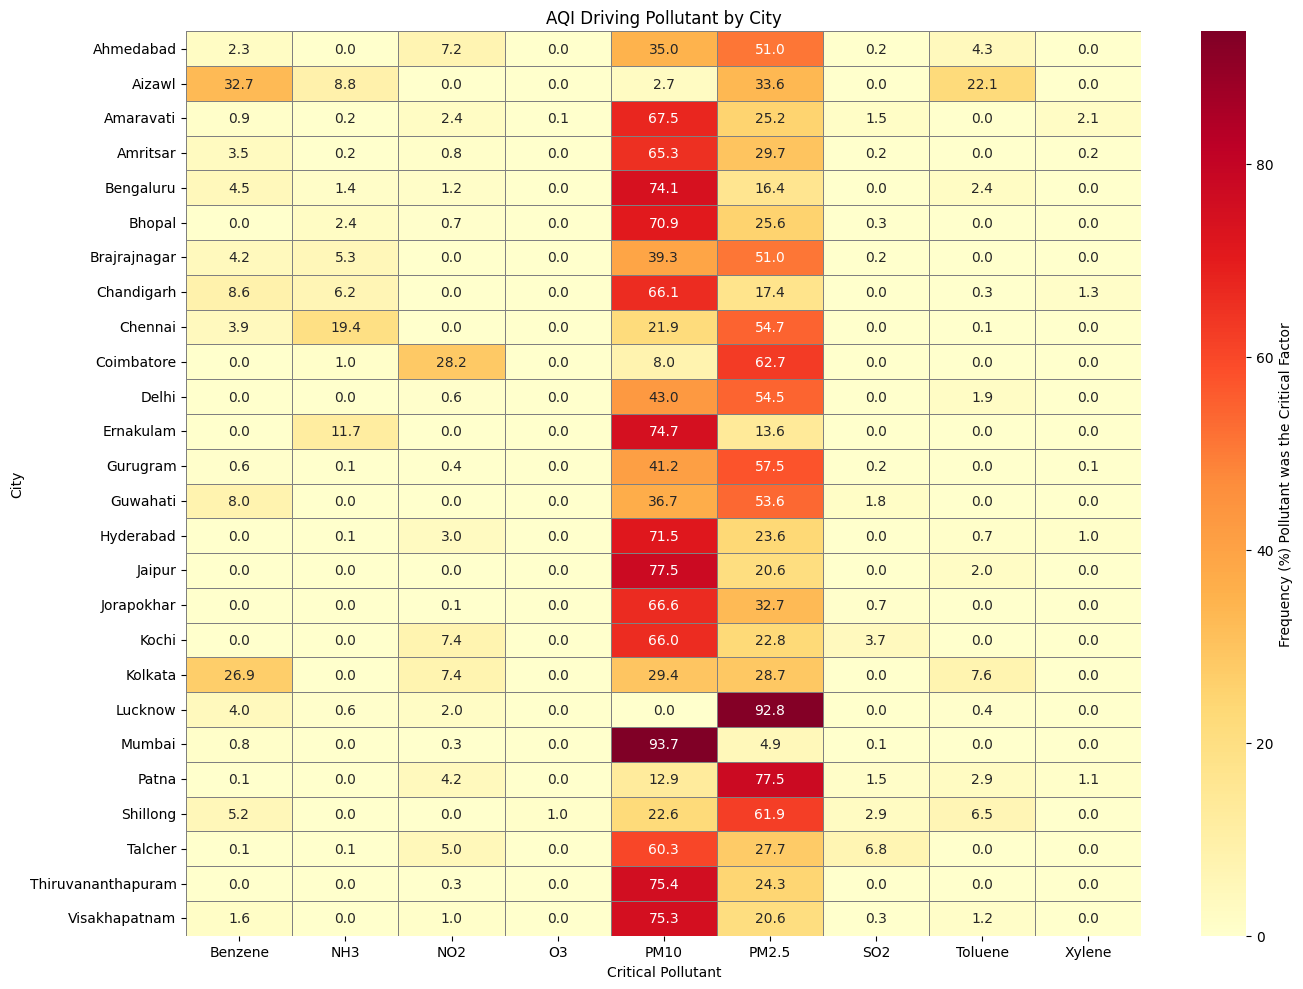

In [34]:
pollutant_frequency = df_city_crit.groupby(['City', 'critical_pollutant']).size().unstack(fill_value=0)
total_days_per_city = pollutant_frequency.sum(axis=1)
frequency_matrix = pollutant_frequency.div(total_days_per_city, axis=0) * 100
frequency_matrix = frequency_matrix.sort_index()

plt.figure(figsize=(14, 10))

sns.heatmap(
    frequency_matrix,
    cmap='YlOrRd',
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Frequency (%) Pollutant was the Critical Factor'}
)

plt.title('AQI Driving Pollutant by City')
plt.xlabel('Critical Pollutant')
plt.ylabel('City')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [35]:
frequency_matrix.to_csv('critical_pollutant.csv')

In [51]:
df_city_final = df_city_[['Date', 'City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'month', 'Season', 'AQI', 'AQI_Bucket']]

In [52]:
df_city_final['Date'] = pd.to_datetime(df_city_final['Date'])

/tmp/ipython-input-73597371.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_city_final['Date'] = pd.to_datetime(df_city_final['Date'])


In [53]:
df_city_final

,Date,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,month,Season,AQI,AQI_Bucket
0,2015-01-01,Ahmedabad,73.24,118.44,0.92,18.22,17.15,0.00,0.92,27.64,133.36,0.00,0.02,0.00,2015-01-01,Winter,142.784828,Moderate
1,2015-01-02,Ahmedabad,73.24,118.44,0.97,15.69,16.46,0.00,0.97,24.55,34.06,3.68,5.50,3.77,2015-01-01,Winter,142.784828,Moderate
2,2015-01-03,Ahmedabad,73.24,118.44,17.40,19.30,29.70,0.00,17.40,29.07,30.70,6.80,16.40,2.25,2015-01-01,Winter,142.784828,Very Poor
3,2015-01-04,Ahmedabad,73.24,118.44,1.70,18.48,17.97,0.00,1.70,18.59,36.08,4.43,10.14,1.00,2015-01-01,Winter,142.784828,Moderate
4,2015-01-05,Ahmedabad,73.24,118.44,22.10,21.42,37.76,0.00,22.10,39.33,39.31,7.01,18.89,2.78,2015-01-01,Winter,142.784828,Very Poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,2020-06-27,Visakhapatnam,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,2020-06-01,Summer,43.107143,Good
29527,2020-06-28,Visakhapatnam,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,2020-06-01,Summer,74.090000,Satisfactory
29528,2020-06-29,Visakhapatnam,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,2020-06-01,Summer,65.730000,Satisfactory
29529,2020-06-30,Visakhapatnam,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,2020-06-01,Summer,49.970000,Good


In [55]:
df_city_final.set_index('Date', inplace = True)

In [56]:
city_weekly_aqi = df_city_final.groupby(df_city_final.index)['AQI'].mean().resample('W').mean()

In [57]:
city_weekly_aqi

,AQI
Date,
2015-01-04,184.081744
2015-01-11,207.619097
2015-01-18,206.197677
2015-01-25,199.846791
2015-02-01,198.256352
...,...
2020-06-07,77.531608
2020-06-14,78.437257
2020-06-21,79.201588


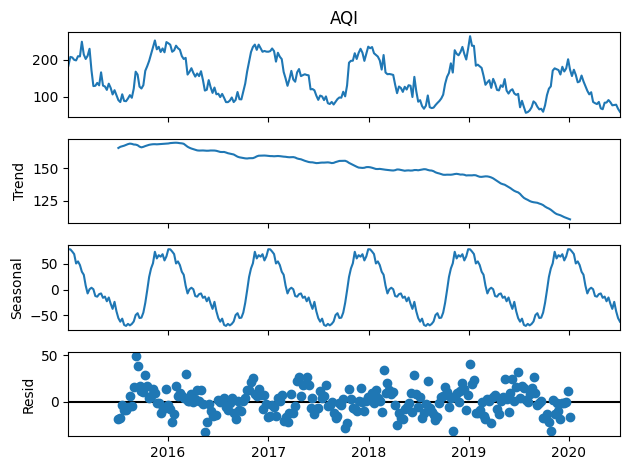

In [58]:
decomposition = seasonal_decompose(city_weekly_aqi.dropna(), model='additive', period=52)
decomposition.plot()
plt.show()

In [59]:
T_add, S_add, I_add = decomposition.trend, decomposition.seasonal, decomposition.resid
reconstructed_add = T_add + S_add + I_add
mse_add = np.mean((city_weekly_aqi.dropna() - reconstructed_add.dropna())**2)
print('MSE with Additive Model', mse_add)

MSE with Additive Model 7.316350632829451e-29


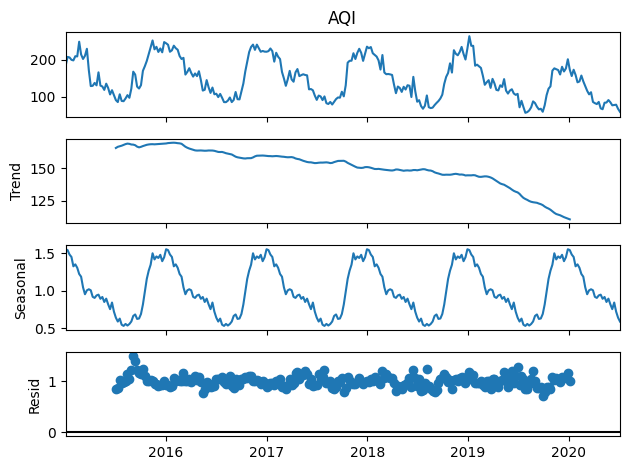

In [60]:
decomposition_m = seasonal_decompose(city_weekly_aqi.dropna(), model='multiplicative', period=52)
decomposition_m.plot()
plt.show()

In [61]:
T_mul, S_mul, I_mul = decomposition_m.trend, decomposition_m.seasonal, decomposition_m.resid
reconstructed_mul = T_mul * S_mul * I_mul
mse_mul = np.mean((city_weekly_aqi.dropna() - reconstructed_mul.dropna())**2)
print('MSE with Multiplicative Model', mse_mul)

MSE with Multiplicative Model 2.3382372051703484e-28


Since the additive model gives a lower MSE, using it for seasonal decomposition stats

In [62]:
trend = decomposition.trend.dropna()

In [72]:
trend.to_csv('trends.csv')

In [81]:
trends_ = decomposition.trend
trends_.to_csv('trends.csv')

In [63]:
trend

,trend
Date,
2015-07-05,165.550718
2015-07-12,166.444361
2015-07-19,166.906071
2015-07-26,167.297881
2015-08-02,167.923070
...,...
2019-12-08,113.350268
2019-12-15,112.636862
2019-12-22,112.084657


In [64]:
total_trend_change = trend.iloc[-1] - trend.iloc[0]
duration_in_days = (trend.index.max() - trend.index.min()).days
duration_in_years = duration_in_days/365.25
decomposition_annual_change = total_trend_change/duration_in_years

print(' Overall Stats')
print(f'Total change in trend over Period: {total_trend_change} AQI')
print(f'Average Annual Change: {decomposition_annual_change} AQI/year')

 Overall Stats
Total change in trend over Period: -54.61188139895242 AQI
Average Annual Change: -12.125829593293235 AQI/year


In [65]:
seasonal = decomposition.seasonal.dropna()
monthly_seasonal_avg = seasonal.groupby(seasonal.index.month).mean()
monthly_seasonal_avg.index = pd.to_datetime(monthly_seasonal_avg.index, format='%m').strftime('%b')

In [78]:
residual = decomposition.resid.dropna()
residual

,resid
Date,
2015-01-04,NaN
2015-01-11,NaN
2015-01-18,NaN
2015-01-25,NaN
2015-02-01,NaN
...,...
2020-06-07,NaN
2020-06-14,NaN
2020-06-21,NaN


In [66]:
seasonal

,seasonal
Date,
2015-01-04,78.744847
2015-01-11,78.574927
2015-01-18,74.250262
2015-01-25,69.330658
2015-02-01,51.011428
...,...
2020-06-07,-37.544712
2020-06-14,-23.827106
2020-06-21,-42.266101


In [67]:
monthly_seasonal_avg

,seasonal
Date,
Jan,70.162568
Feb,42.632511
Mar,2.204616
Apr,-9.096287
May,-16.580504
Jun,-34.826533
Jul,-62.827808
Aug,-66.595424
Sep,-50.789060


In [68]:
peak_month = monthly_seasonal_avg.idxmax()
peak_magnitude = monthly_seasonal_avg.max()
trough_month = monthly_seasonal_avg.idxmin()
trough_magnitude = monthly_seasonal_avg.min()

In [69]:
print('Seasonal Stats')
print(f'Peak Seasonal Month: {peak_month} (Average deviation form trend: {peak_magnitude} AQI)')
print(f'Trough Seasonal Month: {trough_month} (Average deviation form trend: {trough_magnitude} AQI)')
print(f'Total Seasonal Range: {peak_magnitude - trough_magnitude} AQI')

Seasonal Stats
Peak Seasonal Month: Jan (Average deviation form trend: 70.16256789277962 AQI)
Trough Seasonal Month: Aug (Average deviation form trend: -66.59542432780911 AQI)
Total Seasonal Range: 136.75799222058873 AQI


## Festive Spikes

In [70]:
#overlapping diwali and crop burning months (October-November)
fest_date = pd.to_datetime('2019-11-07') # diwali 2019
pollutant_prim = ['PM2.5', 'PM10', 'NO2']
spike_window = pd.date_range(fest_date - pd.Timedelta(days = 7), fest_date + pd.Timedelta(days = 7))
base_window = pd.date_range(fest_date - pd.Timedelta(days = 15), fest_date + pd.Timedelta(days = 15))
df_city_final_ = df_city_final.groupby(df_city_final.index)[pollutant_prim].mean()

spike_avg = df_city_final_.loc[spike_window].mean()
baseline_avg = df_city_final_.loc[base_window].mean()

print('Diwali 2019')
for poll in pollutant_prim:
  print(f'Avg {poll} during spike: {int(spike_avg[poll])}')
  print(f'Avg {poll} during baseline: {int(baseline_avg[poll])}')
  print(f"Percentage increase over baseline: {(int(spike_avg[poll]) / int(baseline_avg[poll]) - 1) * 100:.2f}%")

Diwali 2019
Avg PM2.5 during spike: 91
Avg PM2.5 during baseline: 83
Percentage increase over baseline: 9.64%
Avg PM10 during spike: 132
Avg PM10 during baseline: 122
Percentage increase over baseline: 8.20%
Avg NO2 during spike: 34
Avg NO2 during baseline: 32
Percentage increase over baseline: 6.25%


In [71]:
fest_date = pd.to_datetime('2019-01-01')
pollutant_prim = ['PM2.5', 'PM10', 'NO2']
spike_window = pd.date_range(fest_date - pd.Timedelta(days = 7), fest_date + pd.Timedelta(days = 7))
base_window = pd.date_range(fest_date - pd.Timedelta(days = 15), fest_date + pd.Timedelta(days = 15))
df_city_final_ = df_city_final.groupby(df_city_final.index)[pollutant_prim].mean()

spike_avg = df_city_final_.loc[spike_window].mean()
baseline_avg = df_city_final_.loc[base_window].mean()

print('New Year 2019')
for poll in pollutant_prim:
  print(f'Avg {poll} during spike: {int(spike_avg[poll])}')
  print(f'Avg {poll} during baseline: {int(baseline_avg[poll])}')
  print(f"Percentage increase over baseline: {(int(spike_avg[poll]) / int(baseline_avg[poll]) - 1) * 100:.2f}%")

New Year 2019
Avg PM2.5 during spike: 130
Avg PM2.5 during baseline: 120
Percentage increase over baseline: 8.33%
Avg PM10 during spike: 195
Avg PM10 during baseline: 183
Percentage increase over baseline: 6.56%
Avg NO2 during spike: 47
Avg NO2 during baseline: 44
Percentage increase over baseline: 6.82%
